# Parte 1
Verificación visual. 

In [188]:

pts = [(0, 1), (1, 5), (2, 3)]

In [189]:
def Spline(x, xi, *, a, b, c, d):
    return a + b * (x - xi) + c * (x - xi) ** 2 + d * (x - xi) ** 3

In [190]:
import matplotlib.pyplot as plt
import numpy as np


def dibujar_spline(pts, s):
    xs, ys = zip(*pts)
    for i, x_i in enumerate(xs[:-1]):
        _x = np.linspace(x_i, xs[i + 1], 20)
        _y = Spline(_x, x_i, **s[i])
        plt.plot(_x, _y)

    plt.scatter(xs, ys)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Interpolación con splines cúbicos")
    plt.show()

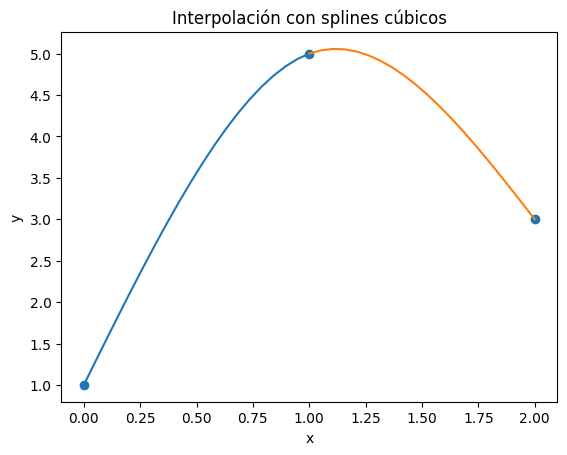

In [191]:
s = [
    {"a": 1, "b": 5.5, "c": 0, "d": -1.5},
    {"a": 5, "b": 1, "c": -4.5, "d": 1.5},
]


dibujar_spline(pts, s)

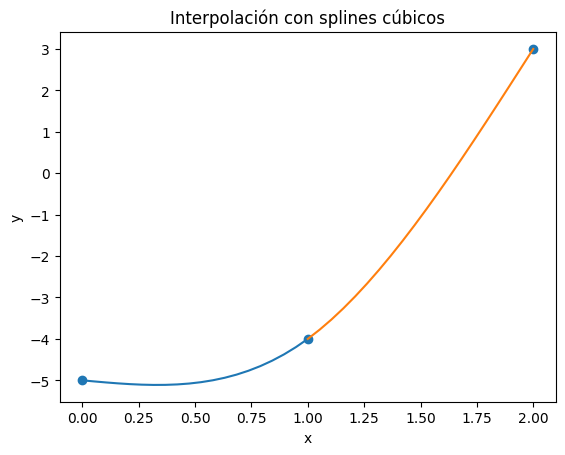

In [192]:
pts = [(0, -5), (1, -4), (2, 3)]

def Spline(x, xi, *, a, b, c, d):
    return a + b * (x - xi) + c * (x - xi) ** 2 + d * (x - xi) ** 3

import matplotlib.pyplot as plt
import numpy as np


def dibujar_spline(pts, s):
    xs, ys = zip(*pts)
    for i, x_i in enumerate(xs[:-1]):
        _x = np.linspace(x_i, xs[i + 1], 20)
        _y = Spline(_x, x_i, **s[i])
        plt.plot(_x, _y)

    plt.scatter(xs, ys)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Interpolación con splines cúbicos")
    plt.show()


s = [
    {"a": -5, "b": -0.5, "c": 0, "d": 1.5},
    {"a": -4, "b": 4, "c": 4.5, "d": -1.5},
]


dibujar_spline(pts, s)

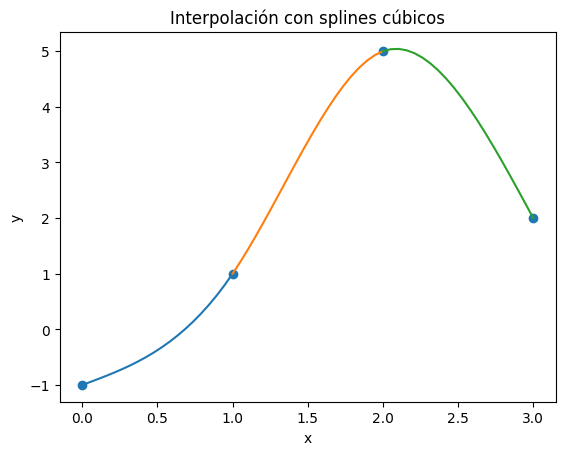

In [193]:
pts = [(0, -1), (1, 1), (2, 5) , (3,2)]

def Spline(x, xi, *, a, b, c, d):
    return a + b * (x - xi) + c * (x - xi) ** 2 + d * (x - xi) ** 3

import matplotlib.pyplot as plt
import numpy as np


def dibujar_spline(pts, s):
    xs, ys = zip(*pts)
    for i, x_i in enumerate(xs[:-1]):
        _x = np.linspace(x_i, xs[i + 1], 20)
        _y = Spline(_x, x_i, **s[i])
        plt.plot(_x, _y)

    plt.scatter(xs, ys)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Interpolación con splines cúbicos")
    plt.show()

s = [
    {"a": -1, "b": 1, "c": 0, "d": 1},
    {"a": 1, "b": 4, "c": 3, "d": -3},
    {"a": 5, "b": 1, "c": -6, "d": 2}
]


dibujar_spline(pts, s)

# Parte 2
Completar código para definir la función Spline.

In [194]:
import numpy as np
import sympy as sym
import matplotlib.pyplot as plt
from IPython.display import display
import ipywidgets as widgets

def cubic_spline(xs: list, ys: list) -> list:
    """
    Retorna lista de dicts con coeficientes {a, b, c, d, xi, xf}
    para cada segmento S_j(x) = a + b(x-xj) + c(x-xj)^2 + d(x-xj)^3
    """
    points = sorted(zip(xs, ys), key=lambda p: p[0])
    xs = [p[0] for p in points]
    ys = [p[1] for p in points]
    n = len(xs) - 1
    h = [xs[i+1] - xs[i] for i in range(n)]

    alpha = [0] * (n + 1)
    for i in range(1, n):
        alpha[i] = (3/h[i])*(ys[i+1] - ys[i]) - (3/h[i-1])*(ys[i] - ys[i-1])

    l = [1]; u = [0]; z = [0]
    for i in range(1, n):
        li = 2*(xs[i+1] - xs[i-1]) - h[i-1]*u[i-1]
        l.append(li)
        u.append(h[i] / li)
        z.append((alpha[i] - h[i-1]*z[i-1]) / li)
    l.append(1); z.append(0)

    c = [0] * (n + 1)
    splines = []
    for j in range(n-1, -1, -1):
        c[j] = z[j] - u[j]*c[j+1]
        b = (ys[j+1] - ys[j])/h[j] - h[j]*(c[j+1] + 2*c[j])/3
        d = (c[j+1] - c[j]) / (3*h[j])
        splines.insert(0, {"a": ys[j], "b": b, "c": c[j], "d": d,
                            "xi": xs[j], "xf": xs[j+1]})
    return splines

def evaluar(sp, x):
    dx = x - sp["xi"]
    return sp["a"] + sp["b"]*dx + sp["c"]*dx**2 + sp["d"]*dx**3 

def mostrar_splines(xs, ys):
    splines = cubic_spline(xs, ys)
    x = sym.Symbol("x")
    
    print(f"Splines cúbicos para {list(zip(xs, ys))}")
    for i, sp in enumerate(splines):
        a, b, c, d, xi, xf = sp["a"], sp["b"], sp["c"], sp["d"], sp["xi"], sp["xf"]
        S = a + b*(x - xi) + c*(x - xi)**2 + d*(x - xi)**3
        print(f"\nS_{i}(x)  en  [{xi}, {xf}]:")
        display(sym.expand(S))
   

mostrar_splines([0, 1, 2], [1, 5, 3])
mostrar_splines([0, 1, 2], [-5, -4, 3])
mostrar_splines([0, 1, 2, 3], [-1, 1, 5, 2])

Splines cúbicos para [(0, 1), (1, 5), (2, 3)]

S_0(x)  en  [0, 1]:


-1.5*x**3 + 5.5*x + 1


S_1(x)  en  [1, 2]:


1.5*x**3 - 9.0*x**2 + 14.5*x - 2.0

Splines cúbicos para [(0, -5), (1, -4), (2, 3)]

S_0(x)  en  [0, 1]:


...

1.0*x**3 + 1.0*x - 1


S_1(x)  en  [1, 2]:


-3.0*x**3 + 12.0*x**2 - 11.0*x + 3.0


S_2(x)  en  [2, 3]:


2.0*x**3 - 18.0*x**2 + 49.0*x - 37.0

PUNTOS: [(0, 1), (1, 5), (2, 3)]
  Ecuaciones:
S_0(x) 


-1.5*x**3 + 5.5*x + 1

S_1(x) 


1.5*x**3 - 9.0*x**2 + 14.5*x - 2.0

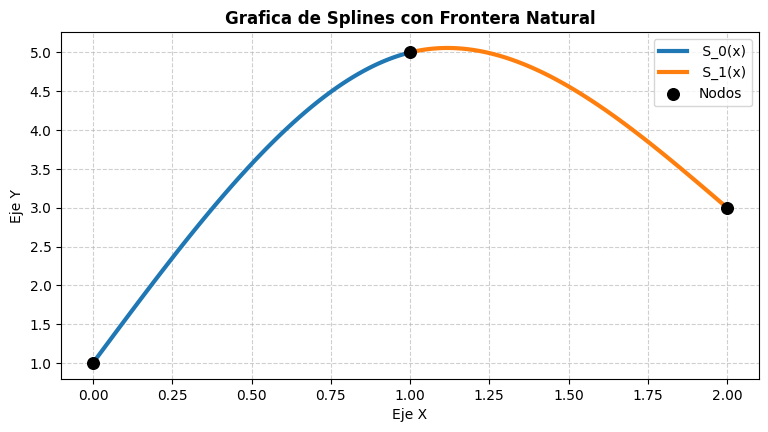

PUNTOS: [(0, -5), (1, -4), (2, 3)]
  Ecuaciones:
S_0(x) 


1.5*x**3 - 0.5*x - 5

S_1(x) 


-1.5*x**3 + 9.0*x**2 - 9.5*x - 2.0

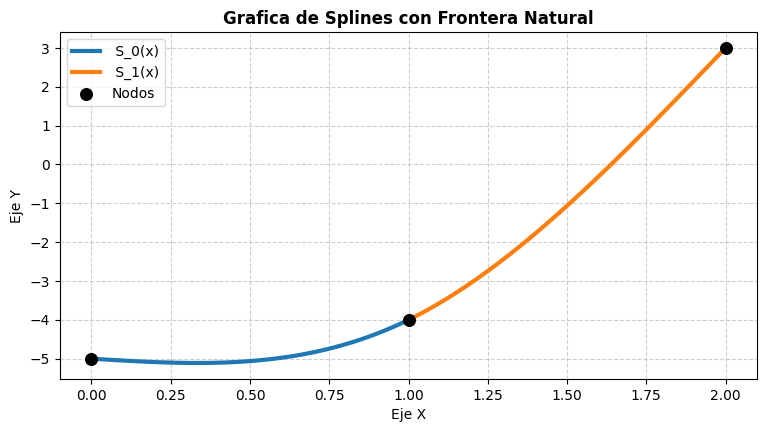

PUNTOS: [(0, -1), (1, 1), (2, 5), (3, 2)]
  Ecuaciones:
S_0(x) 


1.0*x**3 + 1.0*x - 1

S_1(x) 


-3.0*x**3 + 12.0*x**2 - 11.0*x + 3.0

S_2(x) 


2.0*x**3 - 18.0*x**2 + 49.0*x - 37.0

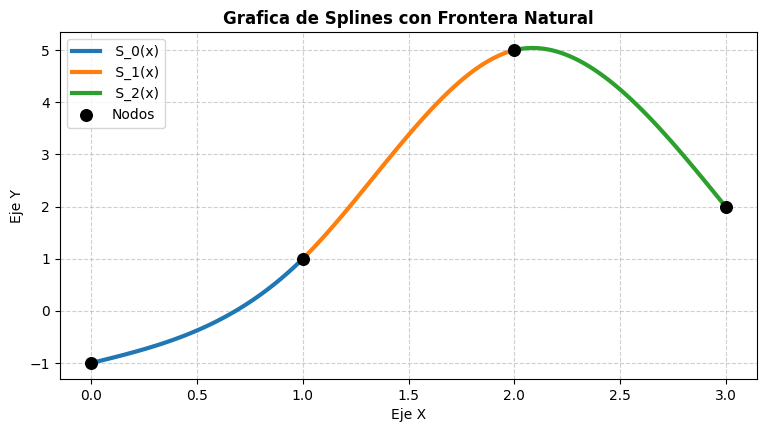

In [195]:


def mostrar_y_graficar_splines(xs, ys):
    """
    Calcula los splines cúbicos, muestra las ecuaciones algebraicas expandidas
    y grafica cada tramo con un color diferente para visualizar las diferencias.
    """
    
    splines = cubic_spline(xs, ys)
    x_sym = sym.Symbol("x")
    

    print(f"PUNTOS: {list(zip(xs, ys))}")
    
   
    print("  Ecuaciones:")
    for i, sp in enumerate(splines):
        a, b, c, d, xi, xf = sp["a"], sp["b"], sp["c"], sp["d"], sp["xi"], sp["xf"]
        S = a + b*(x_sym - xi) + c*(x_sym - xi)**2 + d*(x_sym - xi)**3
        print(f"S_{i}(x) ")
        display(sym.expand(S))
    
    plt.figure(figsize=(9, 4.5))
    
    
    for i, sp in enumerate(splines):
        xi, xf = sp["xi"], sp["xf"]
        x_vals = np.linspace(xi, xf, 100)
        y_vals = [evaluar(sp, val) for val in x_vals]
        
        
        plt.plot(x_vals, y_vals, lw=3, label=f" S_{i}(x)")
        
    
    plt.scatter(xs, ys, color='black', s=70, zorder=5, label="Nodos")
    
    # Estilizado de la gráfica
    plt.title(f"Grafica de Splines con Frontera Natural", fontsize=12, fontweight='bold')
    plt.xlabel("Eje X", fontsize=10)
    plt.ylabel("Eje Y", fontsize=10)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend(loc="best")
    plt.show()


mostrar_y_graficar_splines([0, 1, 2], [1, 5, 3])

mostrar_y_graficar_splines([0, 1, 2], [-5, -4, 3])

mostrar_y_graficar_splines([0, 1, 2, 3], [-1, 1, 5, 2])

In [196]:
import numpy as np
import sympy as sym
import matplotlib.pyplot as plt
from IPython.display import display
import ipywidgets as widgets

def analizador_interactivo(puntos):
    """
    Toma una lista de tuplas (x, y). 
    Fija todos los puntos y vuelve dinámico el ÚLTIMO punto de la lista.
    """

    xs_base = [p[0] for p in puntos[:-1]]
    ys_base = [p[1] for p in puntos[:-1]]
    
    xn_init = puntos[-1][0]
    yn_init = puntos[-1][1]
    
    xn_minimo = xs_base[-1] + 0.1 
    
    y_min_slider = min(ys_base + [yn_init]) - 10.0
    y_max_slider = max(ys_base + [yn_init]) + 10.0
    
  
    
    print(f"PUNTOS BASE: {puntos}")
  
    
    @widgets.interact(
        xn=widgets.FloatSlider(min=xn_minimo, max=xn_init + 5.0, step=0.1, value=xn_init, description='X_n'),
        yn=widgets.FloatSlider(min=y_min_slider, max=y_max_slider, step=0.1, value=yn_init, description='Y_n')
    )
    def actualizar_grafica_y_ecuaciones(xn, yn):
        xs_actuales = xs_base + [xn]
        ys_actuales = ys_base + [yn]
        
        # Recalcular splines con tu función
        splines = cubic_spline(xs_actuales, ys_actuales)
        
        x_sym = sym.Symbol("x")
        print(f"Puntos actuales en el sistema: {list(zip(xs_actuales, ys_actuales))}")
        
        for i, sp_dict in enumerate(splines):
            a, b, c, d = sp_dict["a"], sp_dict["b"], sp_dict["c"], sp_dict["d"]
            xi, xf = sp_dict["xi"], sp_dict["xf"]
            S = a + b*(x_sym - xi) + c*(x_sym - xi)**2 + d*(x_sym - xi)**3
            print(f"  -> S_{i}(x) en [{xi:.2f}, {xf:.2f}]:")
            display(sym.expand(S))
            
        plt.figure(figsize=(10, 5))
        
      
        for i, sp_dict in enumerate(splines):
            xi, xf = sp_dict["xi"], sp_dict["xf"]
            x_vals = np.linspace(xi, xf, 100)
            y_vals = [evaluar(sp_dict, val) for val in x_vals]
            plt.plot(x_vals, y_vals, lw=2.5, label=f"S_{i}(x)")
            
        
        plt.plot(xs_base, ys_base, 'bo', markersize=8, zorder=5, label="Puntos Fijos")
        plt.plot([xn], [yn], 'ro', markersize=10, zorder=6, label="Punto Móvil (X_n, Y_n)")
        
        plt.title("Variación Dinámica del Spline Cúbico")
        plt.xlabel("X")
        plt.ylabel("Y")
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.legend()
        
    
        plt.xlim(xs_base[0] - 1.0, xn_init + 6.0)
        plt.show()

In [ ]:

puntos_ej1 = [(0, 1), (1, 5), (2, 3)]
analizador_interactivo(puntos_ej1)


puntos_ej2 = [(0, -5), (1, -4), (2, 3)]
analizador_interactivo(puntos_ej2)


puntos_ej3 = [(0, -1), (1, 1), (2, 5), (3, 2)]
analizador_interactivo(puntos_ej3)

PUNTOS BASE: [(0, 1), (1, 5), (2, 3)]


interactive(children=(FloatSlider(value=2.0, description='X_n', max=7.0, min=1.1), FloatSlider(value=3.0, desc…

PUNTOS BASE: [(0, -5), (1, -4), (2, 3)]


interactive(children=(FloatSlider(value=2.0, description='X_n', max=7.0, min=1.1), FloatSlider(value=3.0, desc…

PUNTOS BASE: [(0, -1), (1, 1), (2, 5), (3, 2)]


interactive(children=(FloatSlider(value=3.0, description='X_n', max=8.0, min=2.1), FloatSlider(value=2.0, desc…